# Tamanho de Amostra e Introdução a Testes de Hipótese

Continuação de [estimacao_intervalar.ipynb](estimacao_intervalar.ipynb). Agora o
problema se inverte: em vez de partir de uma amostra já coletada e calcular sua margem de
erro, definimos o **erro máximo tolerável** de antemão e calculamos de quantos elementos a
amostra precisa. Na sequência, uma introdução a testes de hipótese usando a mesma lógica
do intervalo de confiança.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'font.size': 12})

## 1. Tamanho de amostra para estimar uma média

Invertendo a fórmula da margem de erro $E = z_{\alpha/2}\cdot\sigma/\sqrt{n}$ para
isolar $n$:

$$n_0 = \left(\frac{z_{\alpha/2}\cdot\sigma}{E}\right)^2$$

Sempre arredondando **para cima** — uma amostra um pouco maior nunca prejudica a
precisão, uma menor pode não atingir o erro desejado.

### Exemplo — planejamento de uma pesquisa

Quer-se estimar a média de uma população normal com erro-padrão de estimativa de, no
máximo, 2 unidades e 90% de confiança. Sabe-se que $\sigma = 10$. De quantos elementos
precisa a amostra?

In [2]:
sigma, erro, confianca = 10, 2, 0.90

z = stats.norm.ppf(1 - (1 - confianca) / 2)
n0 = (z * sigma / erro) ** 2
n_necessario = math.ceil(n0)

print(f"z crítico = {z:.4f}")
print(f"n (antes de arredondar) = {n0:.2f}")
print(f"tamanho de amostra necessário = {n_necessario}")

z crítico = 1.6449
n (antes de arredondar) = 67.64
tamanho de amostra necessário = 68


### Correção para população finita

Se a população é finita e de tamanho $N$ conhecido, o $n_0$ calculado acima pode ser
ajustado para baixo (não faz sentido pedir uma amostra maior que a própria população):

$$n = \frac{n_0}{1 + \dfrac{n_0 - 1}{N}}$$

### Exemplo — amostra piloto e reamostragem

Uma amostra piloto de 15 valores de uma população normal forneceu desvio padrão amostral
$s=4{,}8$. Deseja-se um erro máximo de 0,7 unidade com 95% de confiança. Como o desvio
padrão veio de uma amostra pequena, usa-se o valor crítico $t$ (mais conservador que $z$)
em vez da Normal — isso dá uma exigência de amostra um pouco maior, refletindo a incerteza
extra de estimar $\sigma$ a partir de poucos dados.

In [3]:
s_piloto, erro2, confianca2, n_piloto = 4.8, 0.7, 0.95, 15
df = n_piloto - 1

t_critico = stats.t.ppf(1 - (1 - confianca2) / 2, df=df)
z_critico = stats.norm.ppf(1 - (1 - confianca2) / 2)

n0_com_t = (t_critico * s_piloto / erro2) ** 2
n0_com_z = (z_critico * s_piloto / erro2) ** 2

print(f"usando t (df={df}) : n0 = {n0_com_t:.1f}  ->  n = {math.ceil(n0_com_t)}")
print(f"usando z            : n0 = {n0_com_z:.1f}  ->  n = {math.ceil(n0_com_z)}")
print(f"faltam {math.ceil(n0_com_t) - n_piloto} elementos para completar a amostra piloto")

usando t (df=14) : n0 = 216.3  ->  n = 217
usando z            : n0 = 180.6  ->  n = 181
faltam 202 elementos para completar a amostra piloto


## 2. Tamanho de amostra para estimar uma proporção

Mesma lógica, com a fórmula da margem de erro de proporção:

$$n_0 = \frac{z_{\alpha/2}^2 \cdot \hat{p}(1-\hat{p})}{E^2}$$

Quando não se tem nenhuma estimativa prévia de $\hat{p}$, usa-se $\hat{p}=0{,}5$ (o
valor que maximiza $\hat{p}(1-\hat{p})$, e portanto o tamanho de amostra — a escolha
"mais conservadora").

### Exemplo — pesquisa de opinião com pré-amostra

Uma pré-amostra de 50 pessoas revelou que 70% pertenciam a um determinado perfil. Deseja-se
90% de confiança com erro máximo de 4% na estimativa final. Qual o tamanho de amostra
necessário?

In [4]:
p_chapeu, erro3, confianca3 = 0.70, 0.04, 0.90

z3 = stats.norm.ppf(1 - (1 - confianca3) / 2)
n0_prop = (z3 ** 2) * p_chapeu * (1 - p_chapeu) / (erro3 ** 2)
n_prop = math.ceil(n0_prop)

print(f"n (antes de arredondar) = {n0_prop:.1f}")
print(f"tamanho de amostra necessário = {n_prop}")

n (antes de arredondar) = 355.1
tamanho de amostra necessário = 356


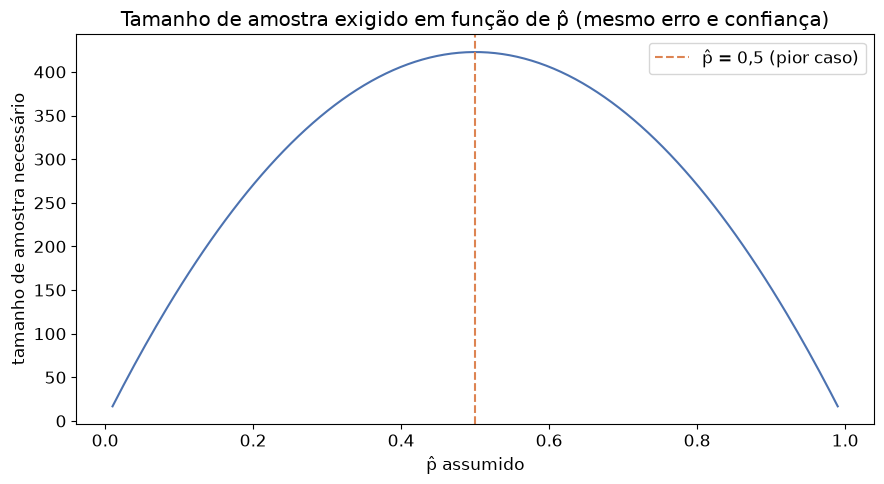

In [5]:
# Efeito do "chute" de p_hat no tamanho de amostra exigido
p_vals = np.linspace(0.01, 0.99, 200)
n_vals = (z3 ** 2) * p_vals * (1 - p_vals) / (erro3 ** 2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p_vals, n_vals, color='#4C72B0')
ax.axvline(0.5, color='#DD8452', linestyle='--', label='p̂ = 0,5 (pior caso)')
ax.set_title('Tamanho de amostra exigido em função de p̂ (mesmo erro e confiança)')
ax.set_xlabel('p̂ assumido')
ax.set_ylabel('tamanho de amostra necessário')
ax.legend()
plt.tight_layout()
plt.savefig('img_tamanho_amostra_proporcao.png', dpi=110)
plt.show()

## 3. Introdução a testes de hipótese

Um teste de hipótese avalia se um valor **hipotetizado** para um parâmetro populacional é
plausível, à luz dos dados observados. A forma mais direta de fazer isso na prática (e a
que conecta diretamente com tudo que já foi construído neste notebook): **construir um
intervalo de confiança e verificar se o valor hipotetizado cai dentro dele.**

- Se o valor hipotetizado está **fora** do intervalo → rejeita-se a hipótese, ao nível de
  significância $\alpha = 1 - \text{confiança}$.
- Se está **dentro** → os dados não fornecem evidência suficiente para rejeitá-la (o que
  não é o mesmo que "provar" que ela é verdadeira).

### Exemplo — valor médio de uma carteira de títulos

Uma amostra de 10 títulos de uma carteira, com variância populacional conhecida de
400 (u.m.²), forneceu os valores: 80, 120, 71, 120, 140, 200, 180, 70, 45, 87. O
responsável pela carteira afirma que o valor médio dos títulos é 125. Os dados sustentam
essa afirmação, a 90% de confiança?

In [6]:
titulos = np.array([80, 120, 71, 120, 140, 200, 180, 70, 45, 87])
sigma_t = math.sqrt(400)
n_t = len(titulos)
media_t = titulos.mean()
valor_hipotetizado = 125
confianca_t = 0.90

z_t = stats.norm.ppf(1 - (1 - confianca_t) / 2)
margem_t = z_t * sigma_t / math.sqrt(n_t)
ic_t = (media_t - margem_t, media_t + margem_t)

print(f"média amostral = {media_t:.2f}")
print(f"IC {confianca_t:.0%}: ({ic_t[0]:.2f}, {ic_t[1]:.2f})")

dentro = ic_t[0] <= valor_hipotetizado <= ic_t[1]
print(f"\nO valor hipotetizado ({valor_hipotetizado}) está dentro do IC? {dentro}")
print("Conclusão:", "não há evidência para rejeitar a afirmação."
      if dentro else "a afirmação é rejeitada a este nível de confiança.")

média amostral = 111.30
IC 90%: (100.90, 121.70)

O valor hipotetizado (125) está dentro do IC? False
Conclusão: a afirmação é rejeitada a este nível de confiança.


### Exemplo — proporção em um grupo

Uma amostra de 100 pessoas de um curso superior mostrou que 40% eram mulheres. Um artigo
afirma que a proporção de mulheres no curso é **maior que a de homens** (ou seja,
$p > 0{,}50$). Isso é necessariamente falso, a 98% de confiança?

In [7]:
p_amostra, n_amostra, confianca_p = 0.40, 100, 0.98

z_p = stats.norm.ppf(1 - (1 - confianca_p) / 2)
margem_p = z_p * math.sqrt(p_amostra * (1 - p_amostra) / n_amostra)
ic_p = (p_amostra - margem_p, p_amostra + margem_p)

print(f"IC {confianca_p:.0%} para a proporção: ({ic_p[0]:.4f}, {ic_p[1]:.4f})")

if ic_p[1] > 0.50:
    print("\nO limite superior do IC ultrapassa 0,50: a afirmação NÃO pode ser descartada")
    print("como falsa — 0,50 (e valores maiores) ainda são estatisticamente plausíveis,")
    print("mesmo a proporção amostral observada sendo de apenas 40%.")
else:
    print("\nO IC inteiro fica abaixo de 0,50: a afirmação é rejeitada a este nível de confiança.")

IC 98% para a proporção: (0.2860, 0.5140)

O limite superior do IC ultrapassa 0,50: a afirmação NÃO pode ser descartada
como falsa — 0,50 (e valores maiores) ainda são estatisticamente plausíveis,
mesmo a proporção amostral observada sendo de apenas 40%.


## 4. Exercícios de fixação

1. Deseja-se estimar uma média populacional com erro máximo de 5 unidades e 95% de
   confiança, sabendo que $\sigma = 25$. Qual o tamanho de amostra necessário?
2. Uma pesquisa quer estimar uma proporção com erro máximo de 3% e 95% de confiança, sem
   nenhuma estimativa prévia de $\hat{p}$ (use o pior caso, $\hat{p}=0{,}5$). Qual o
   tamanho de amostra?
3. Um fabricante afirma que a vida útil média de uma peça é de 1000 horas. Uma amostra de
   20 peças teve vida média de 950 horas, desvio padrão amostral de 80 horas. A 95% de
   confiança, os dados contradizem a afirmação do fabricante?

In [8]:
# 1.
z1 = stats.norm.ppf(1 - 0.05 / 2)
n1 = math.ceil((z1 * 25 / 5) ** 2)
print(f"1) n = {n1}")

# 2.
z2 = stats.norm.ppf(1 - 0.05 / 2)
n2 = math.ceil((z2 ** 2) * 0.5 * 0.5 / (0.03 ** 2))
print(f"2) n = {n2}")

# 3.
t3 = stats.t.ppf(1 - 0.05 / 2, df=19)
margem3 = t3 * 80 / math.sqrt(20)
ic3 = (950 - margem3, 950 + margem3)
print(f"3) IC 95%: ({ic3[0]:.2f}, {ic3[1]:.2f})  |  1000 dentro do IC? {ic3[0] <= 1000 <= ic3[1]}")

1) n = 97
2) n = 1068
3) IC 95%: (912.56, 987.44)  |  1000 dentro do IC? False


## Encerramento do módulo

Com a estimação intervalar e a determinação de tamanho de amostra, o Módulo 04 está
completo. O [Módulo 05 — Correlação e Regressão Linear](../05_Correlação_e_Regressão_Linear)
usa essas mesmas ferramentas de inferência (erro padrão, intervalo de confiança, teste de
hipótese) aplicadas aos coeficientes de um modelo de regressão.

## Bibliografia
- TRIOLA, Mario F. *Introdução à Estatística*. 8. ed. Rio de Janeiro: LTC, 2005.
- BUSSAB, Wilton O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva, 2017.
- MOORE, David S.; McCABE, George P.; CRAIG, Bruce A. *Introduction to the Practice of Statistics*. 9. ed. W. H. Freeman, 2017.
- WOOLDRIDGE, Jeffrey M. *Introdução à Econometria: uma abordagem moderna*. São Paulo: Cengage Learning, 2016.